Aquí vamos a mostrar lo siguiente, con los siguientes datos:

En este notebook realizamos un análisis de datos sobre 50 centros de datos
de España para apoyar la toma de decisiones de FutureTech en materia de
sostenibilidad y economía circular.

El objetivo es identificar qué centros de datos tienen mayor impacto ambiental,
cuáles son los más eficientes, y qué medidas concretas debería aplicar FutureTech
para reducir su huella de carbono, optimizar el consumo energético y gestionar
mejor sus recursos hídricos.

Los datos analizados incluyen consumo de agua, consumo de energía, emisiones
de CO2, eficiencia energética (PUE), residuos electrónicos, porcentaje de
energía renovable y número de servidores.

1- El centro de datos que más consume agua consume, energía. //Marta

2- Top 10 más sostenibles. //Marta

3- Consumo medio de los centros de datos. //Marta

4- Consumo medio de los centros de datos. //Ibon

5- Gráfico top 10 más sostenibles por energía. //Ibon (IA)

6- Centros de datos con peor PUE. //Ibon

7- Relación entre energía renovable y emisiones de CO2. /Ibon

8- Comparativa del centro de datos piloto CDM-Madrid-01 vs la media del sector. //Ibon

9- Consumo de energía por servidor //Ibai

10- Potencial de ahorro si todos mejoraran al nivel del top 10 //Ibai


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("datos_data_center.csv")

In [3]:
df
len(df)

50

In [4]:
df.iloc[df['agua_consumida_m3_anual'].idxmax()]

,10
nombre_centro_datos,DC-11 Microsoft Valencia
localizacion,Valencia
agua_consumida_m3_anual,179496
energia_consumida_MWh_anual,428017
emisiones_CO2_toneladas,172.6
PUE,2.2
residuos_electronicos_kg,3500
porcentaje_energia_renovable,22
num_servidores,580


In [5]:
df.iloc[df['energia_consumida_MWh_anual'].idxmax()]

,31
nombre_centro_datos,DC-32 Google Málaga
localizacion,Málaga
agua_consumida_m3_anual,93343
energia_consumida_MWh_anual,435352
emisiones_CO2_toneladas,175.2
PUE,2.22
residuos_electronicos_kg,3600
porcentaje_energia_renovable,21
num_servidores,590


In [6]:
df.columns

Index(['nombre_centro_datos', 'localizacion', 'agua_consumida_m3_anual',
       'energia_consumida_MWh_anual', 'emisiones_CO2_toneladas', 'PUE',
       'residuos_electronicos_kg', 'porcentaje_energia_renovable',
       'num_servidores'],
      dtype='object')

In [7]:
top_10_sostenibles_agua = (
    df.groupby('nombre_centro_datos')['agua_consumida_m3_anual']
      .mean()
      .sort_values(ascending=True)
      .head(10)
)

In [8]:
top_10_sostenibles_agua

,agua_consumida_m3_anual
nombre_centro_datos,
DC-30 Digital Realty Bilbao,23797.0
DC-07 Amazon AWS Zaragoza,33178.0
DC-05 Amazon AWS Barcelona,34251.0
DC-22 Google Sevilla,35832.0
DC-17 Telefónica Bilbao,41524.0
DC-13 Digital Realty Sevilla,47122.0
DC-36 Amazon AWS Valencia,48531.0
DC-25 Microsoft Madrid,58721.0
DC-33 Equinix Valencia,60581.0


In [9]:
top_10_sostenibles_energia = (
   df.groupby('nombre_centro_datos')['energia_consumida_MWh_anual']
      .mean()
      .sort_values(ascending=True)
      .head(10)
)


In [10]:
top_10_sostenibles_energia

,energia_consumida_MWh_anual
nombre_centro_datos,
DC-44 Microsoft Zaragoza,87827.0
DC-13 Digital Realty Sevilla,114444.0
DC-38 Telefónica Barcelona,115732.0
DC-36 Amazon AWS Valencia,115854.0
DC-40 Amazon AWS Madrid,117055.0
DC-12 Amazon AWS Zaragoza,119665.0
DC-19 Digital Realty Madrid,127988.0
DC-33 Equinix Valencia,130486.0
DC-23 Digital Realty Barcelona,133665.0


In [11]:
consumo_medio = df[['agua_consumida_m3_anual', 'energia_consumida_MWh_anual']].mean()
consumo_medio

,0
agua_consumida_m3_anual,96892.28
energia_consumida_MWh_anual,250904.98


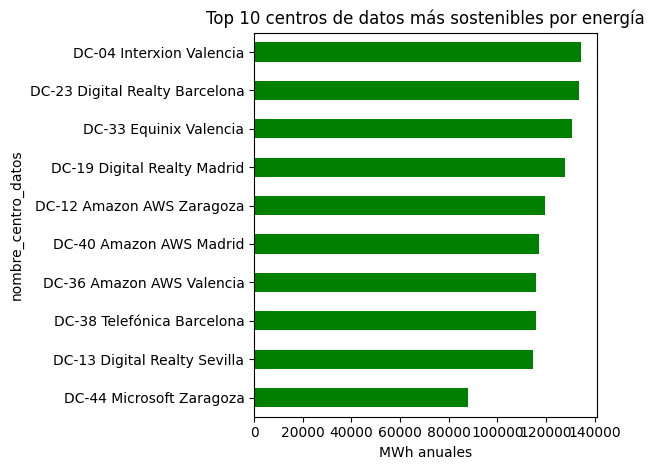

In [ ]:
import matplotlib.pyplot as plt

# Gráfico top 10 más sostenibles por energía
top_10_sostenibles_energia.plot(kind='barh', color='green')
plt.title('Top 10 centros de datos más sostenibles por energía')
plt.xlabel('MWh anuales')
plt.tight_layout()
plt.show()

In [12]:
peor_pue = df.nlargest(5, 'PUE')[['nombre_centro_datos', 'PUE', 'energia_consumida_MWh_anual']]
peor_pue

,nombre_centro_datos,PUE,energia_consumida_MWh_anual
31,DC-32 Google Málaga,2.22,435352
48,DC-49 Google Sevilla,2.21,428269
10,DC-11 Microsoft Valencia,2.20,428017
46,DC-47 Digital Realty Barcelona,2.19,418122
23,DC-24 Equinix Bilbao,2.18,407940


In [13]:
df_sorted = df.sort_values('porcentaje_energia_renovable', ascending=False)
df_sorted[['nombre_centro_datos', 'porcentaje_energia_renovable', 'emisiones_CO2_toneladas']].head(10)

,nombre_centro_datos,porcentaje_energia_renovable,emisiones_CO2_toneladas
43,DC-44 Microsoft Zaragoza,88,62.4
12,DC-13 Digital Realty Sevilla,80,70.1
35,DC-36 Amazon AWS Valencia,80,71.8
32,DC-33 Equinix Valencia,79,77.4
39,DC-40 Amazon AWS Madrid,79,74.6
37,DC-38 Telefónica Barcelona,79,73.5
11,DC-12 Amazon AWS Zaragoza,78,75.3
22,DC-23 Digital Realty Barcelona,77,79.8
18,DC-19 Digital Realty Madrid,75,82.1
26,DC-27 Digital Realty Zaragoza,72,86.2


In [14]:
media_pue = df['PUE'].mean()
media_energia = df['energia_consumida_MWh_anual'].mean()
media_agua = df['agua_consumida_m3_anual'].mean()
media_renovable = df['porcentaje_energia_renovable'].mean()

print(f"Media PUE del sector: {media_pue:.2f}")
print(f"Media energía del sector: {media_energia:.0f} MWh")
print(f"Media agua del sector: {media_agua:.0f} m3")
print(f"Media energía renovable: {media_renovable:.1f}%")

# Comparar con CDM-Madrid-01 (vuestro centro piloto)
piloto = df[df['nombre_centro_datos'] == 'CDM-Madrid-01'].iloc[0]
print(f"\nCDM-Madrid-01 PUE: {piloto['PUE']} vs media sector: {media_pue:.2f}")
print(f"CDM-Madrid-01 energía renovable: {piloto['porcentaje_energia_renovable']}% vs media: {media_renovable:.1f}%")

Media PUE del sector: 1.70
Media energía del sector: 250905 MWh
Media agua del sector: 96892 m3
Media energía renovable: 51.8%

CDM-Madrid-01 PUE: 1.85 vs media sector: 1.70
CDM-Madrid-01 energía renovable: 35% vs media: 51.8%


In [15]:

df['consumo_por_servidor'] = df['energia_consumida_MWh_anual'] / df['num_servidores']
df.nlargest(5, 'consumo_por_servidor')[['nombre_centro_datos', 'consumo_por_servidor', 'PUE']]

,nombre_centro_datos,consumo_por_servidor,PUE
40,DC-41 Interxion Sevilla,803.107843,1.80
7,DC-08 Equinix Bilbao,800.908889,1.90
29,DC-30 Digital Realty Bilbao,797.525301,1.81
16,DC-17 Telefónica Bilbao,795.061905,1.82
44,DC-45 Amazon AWS Málaga,789.153110,1.81


In [17]:
mejor_pue = top_10_sostenibles_energia.mean()
ahorro_potencial = df['energia_consumida_MWh_anual'].sum() - (mejor_pue * len(df))
print(f"Ahorro potencial: {ahorro_potencial:.0f} MWh anuales")
print(f"Equivale a reducir {ahorro_potencial * 0.25:.0f} toneladas de CO2 al año")

Ahorro potencial: 6560644 MWh anuales
Equivale a reducir 1640161 toneladas de CO2 al año


## Conclusión y decisión final --> hecho por Ibon, Marta e Ibai

El análisis realizado sobre los 50 centros de datos permite a FutureTech
tomar las siguientes decisiones concretas:

- **Prioridad de intervención**: DC-32 Google Málaga y DC-11 Microsoft Valencia
  son los más críticos con PUE superior a 2.20 y menos del 22% de energía
  renovable. Son los primeros candidatos para aplicar las medidas de FutureTech.

- **Objetivo de mejora del piloto**: CDM-Madrid-01 tiene un PUE de 1.85,
  por encima de la media del sector (1.70), y solo un 35% de energía renovable
  frente al 51.8% de media. FutureTech debe reducir su PUE por debajo de 1.4
  en el primer año.

- **Transición renovable**: Los centros más sostenibles como DC-44 Microsoft
  Zaragoza ya alcanzan el 88% de energía renovable con solo 62.4 toneladas
  de CO2. Este es el modelo a seguir.

- **Residuos electrónicos**: Los centros con peor PUE generan más de 3500 kg
  de residuos electrónicos anuales. FutureTech aplicará el protocolo de
  desmontaje y reciclaje para reducirlo en un 90%.